In [1]:
import duckdb
import json
import pandas as pd

from rampa.routing.route import Network, geocoder, ruta_to_json
import duckdb
import json
import pandas as pd
import math
from typing import List, Optional
from rampa.config import config
from tqdm import tqdm



In [2]:
network = Network(db=config.paths['grafo_db'])

Loading network from database
Generating contraction hierarchies with 1 threads.
Setting CH node vector of size 166318
Setting CH edge vector of size 498566
Range graph removed 504470 edges of 997132
. 10% . 20% . 30% . 40% . 50% . 60% . 70% . 80% . 90% . 100%
Generating contraction hierarchies with 1 threads.
Setting CH node vector of size 166318
Setting CH edge vector of size 498566
Range graph removed 504470 edges of 997132
. 10% . 20% . 30% . 40% . 50% . 60% . 70% . 80% . 90% . 100%


In [4]:
coord1 = (-3.700478762379809, 40.4225818197113 )
coord2 = (-3.704474352567631, 40.41645453847468)
ff = network.route_gdf(coord1, coord2, alternate=False)

In [ ]:
ff

In [ ]:
df.columns

In [ ]:
df

In [ ]:
df.to_dict(orient="records")

In [ ]:
ruta_to_json(ff)

In [ ]:
import geopandas as gpd

In [ ]:
sc = gpd.read_file('/Users/mherrero/Documents/madrid_open_data/rampa/data/Secciones_Censales/SECCIONES_CENSALES.shp')

In [ ]:
sc.plot()

In [ ]:
def get_accesibility(gdf, network: Network):


    edges = network.edges
    edges['geometry'] = edges.apply(lambda row: network.get_linestring(row), axis=1)
    sindex = gdf.sindex

    for i, geom in tqdm(enumerate(edges.geometry)):
        # Filtrar posibles intersecciones por bounding box
        possible_idx = list(sindex.intersection(geom.bounds))
        possible_matches = gdf.iloc[possible_idx]
                    
        # Filtrar solo las que realmente intersectan
        intersecting = possible_matches[possible_matches.geometry.intersects(geom)]
        
    return None
                

In [ ]:
e

In [ ]:
def lines_in_polygons(polygons_gdf, lines_gdf, polygon_id_col=None, line_id_col=None, crs='EPSG:3857'):
    """
    Returns lines intersecting polygons with the ratio of each line's length inside the polygon.
    """

    # Ensure same projected CRS
    polygons = polygons_gdf.to_crs(crs).copy()
    lines = lines_gdf.to_crs(crs).copy()

    # If no ID column is provided, create one
    if polygon_id_col is None or polygon_id_col not in polygons.columns:
        polygons['poly_id'] = polygons.index
        polygon_id_col = 'poly_id'

    if line_id_col is None or line_id_col not in lines.columns:
        lines['line_id'] = lines.index
        line_id_col = 'line_id'

    # Keep IDs
    polygons = polygons[[polygon_id_col, 'COD_SECCIO', 'NOM_BAR', 'NOM_DIS', 'geometry']]
    lines = lines[[line_id_col, 'accesibility', 'geometry']]

    # Get intersection geometries
    line_segments = gpd.overlay(lines, polygons, how='intersection')

    # Compute lengths
    line_segments['length_inside'] = line_segments.geometry.length

    # Total line lengths
    lines['length_total'] = lines.geometry.length
    lines['accesibility'] = lines['accesibility']

    # Merge total length
    line_segments = line_segments.merge(lines[[line_id_col, 'length_total']], on=line_id_col)

    # Ratio inside
    line_segments['ratio_inside'] = line_segments['length_inside'] / line_segments['length_total']

    return line_segments


In [ ]:
edges = network.edges
edges['geometry'] = edges.apply(lambda row: network.get_linestring(row), axis=1)
edges = gpd.GeoDataFrame(edges, geometry='geometry', crs='EPSG:4326')

In [ ]:
sc = sc.to_crs(25830)
edges = edges.to_crs(25830)

In [ ]:
print(sc.total_bounds)     # bounding box of polygons
print(edges.total_bounds)  # bounding box of lines

In [ ]:
res = lines_in_polygons(sc, edges)

In [ ]:
res.columns

In [ ]:
res_acc = res[res['accesibility'] ==1]
res_no_acc = res[res['accesibility'] ==0]

In [ ]:
acc = res_acc.groupby('poly_id').agg({
    'COD_SECCIO': 'first',
    'length_inside': 'sum',
    'NOM_BAR': 'first',
    'NOM_DIS': 'first'
}).reset_index()


In [ ]:
no_acc = res_no_acc.groupby('poly_id').agg({
    'COD_SECCIO': 'first',
    'length_inside': 'sum',
    'NOM_BAR': 'first',
    'NOM_DIS': 'first'
}).reset_index()

In [ ]:
cs = acc.merge(no_acc, on=['poly_id', 'COD_SECCIO'], how='outer', suffixes=('_acc', '_no_acc')).fillna(0)

In [ ]:
cs['ratio'] =100 * cs['length_inside_acc'] /(cs['length_inside_no_acc']+cs['length_inside_acc'])

In [ ]:
ccc = cs.merge(sc[['COD_SECCIO', 'geometry']], on='COD_SECCIO')

In [ ]:
ccc = gpd.GeoDataFrame(ccc, geometry='geometry', crs='EPSG:25830')
ccc.loc[ccc['NOM_DIS_no_acc'] == 0, 'NOM_DIS_no_acc'] = ccc.loc[ccc['NOM_DIS_no_acc'] == 0, 'NOM_DIS_acc']
ccc.loc[ccc['NOM_BAR_no_acc'] == 0, 'NOM_BAR_no_acc'] = ccc.loc[ccc['NOM_BAR_no_acc'] == 0, 'NOM_BAR_acc']


<Axes: >

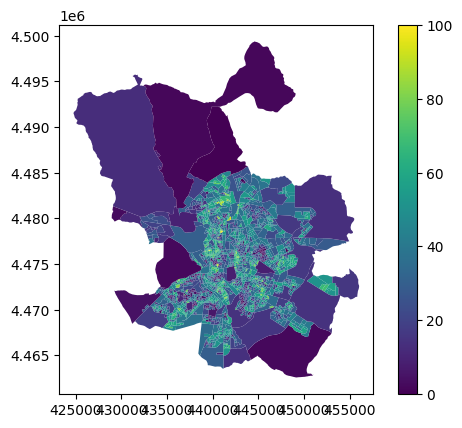

In [152]:
ccc.plot(column='ratio', cmap='viridis', legend=True)

<Axes: >

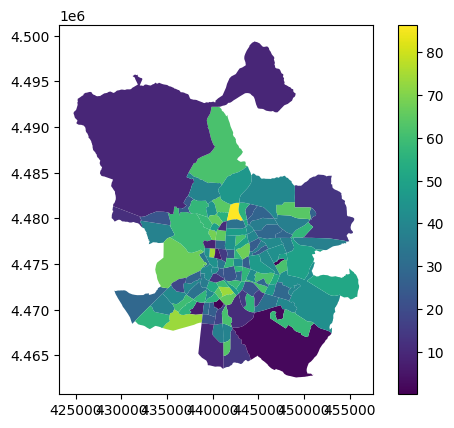

In [150]:
ccc.dissolve(by='NOM_BAR_no_acc', as_index=False).plot(column='ratio', cmap='viridis', legend=True)


<Axes: >

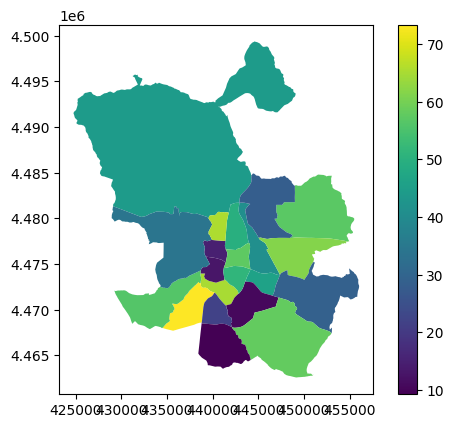

In [151]:
ccc.dissolve(by='NOM_DIS_no_acc', as_index=False).plot(column='ratio', cmap='viridis', legend=True)


In [153]:
ccc

,poly_id,COD_SECCIO,length_inside_acc,NOM_BAR_acc,NOM_DIS_acc,length_inside_no_acc,NOM_BAR_no_acc,NOM_DIS_no_acc,ratio,geometry
0,0,17120,835.893276,"Villaverde alto, Casco Histórico de Villaverde",Villaverde,8155.316880,"Villaverde alto, Casco Histórico de Villaverde",Villaverde,9.296783,"POLYGON ((441169.497 4465067.449, 440908.086 4..."
1,1,17042,2403.045720,San Cristóbal,Villaverde,1386.708650,San Cristóbal,Villaverde,63.409010,"POLYGON ((441660.649 4465831.887, 441715.328 4..."
2,2,17041,7609.381920,San Cristóbal,Villaverde,6936.177144,San Cristóbal,Villaverde,52.314125,"POLYGON ((441549.769 4465831.988, 441551.448 4..."
3,3,17039,5746.075674,San Cristóbal,Villaverde,3025.097538,San Cristóbal,Villaverde,65.510913,"POLYGON ((441203.193 4465933.861, 441276.782 4..."
4,4,17117,14102.361727,Butarque,Villaverde,87626.312824,Butarque,Villaverde,13.862720,"POLYGON ((443619.672 4465966.522, 443633.845 4..."
...,...,...,...,...,...,...,...,...,...,...
2459,2457,08003,925.210292,El Pardo,Fuencarral - El Pardo,8925.602163,El Pardo,Fuencarral - El Pardo,9.392223,"POLYGON ((434248.218 4485691.213, 434266.667 4..."
2460,2458,08001,912.993636,El Pardo,Fuencarral - El Pardo,9383.282490,El Pardo,Fuencarral - El Pardo,8.867222,"POLYGON ((433831.509 4487420.414, 433835.599 4..."
2461,2459,08129,1961.402281,El Goloso,Fuencarral - El Pardo,606864.224732,El Goloso,Fuencarral - El Pardo,0.322162,"POLYGON ((440620.416 4492208.432, 440620.775 4..."
2462,2460,08002,17490.523698,El Pardo,Fuencarral - El Pardo,120579.263712,El Pardo,Fuencarral - El Pardo,12.667886,"POLYGON ((431528.856 4495745.636, 431532.125 4..."


In [3]:
from rampa.analysis.tools import analysis

In [4]:
analysis(network)

Loading data...
Computing line-polygon intersections...
Generating outputs...
Done.


In [7]:
import geopandas as gpd
import duckdb
from rampa.config import config

db_connection = duckdb.connect(config.paths['pois_db'])


In [8]:
df = gpd.read_file('/Users/mherrero/Documents/madrid_open_data/rampa/data/seccion.geojson')

In [23]:
import math
def get_layer(layer_name: str):
    """
    Layer names in fact_demographics table:

    total_population = Column(Integer)
    density = Column(Float)
    edad_promedio = Column(Float)
    proporcion_juventud = Column(Float)
    proporcion_envejecimiento = Column(Float)
    proporcion_sobreenvejecimiento = Column(Float)
    indice_envejecimiento = Column(Float)
    indice_juventud = Column(Float)
    indice_dependencia = Column(Float)
    indice_estructura_poblacion_act = Column(Float)
    indice_reemplazo_poblacion_acti = Column(Float)
    razon_progresividad_demografica = Column(Float)
    """
    # Join fact_demographics with dim_geography to get geometry (geom) for each census_section_id
    df = db_connection.execute(
        f"""
        SELECT fd.census_section_id, fd.{layer_name}, dg.geom
        FROM fact_demographics fd
        JOIN dim_geography dg
        ON fd.census_section_id = dg.census_section_id
        """
    ).fetchdf()
    # Convert DataFrame to list of dicts
    records = df.to_dict(orient="records")

    # Recursively replace NaN and infinite values with None
    def clean_value(v):
        if isinstance(v, float) and (math.isnan(v) or math.isinf(v)):
            return None
        return v

    cleaned_records = [
        {k: clean_value(v) for k, v in record.items()}
        for record in records
    ]

    return cleaned_records

In [24]:
ff = get_layer('density')

In [25]:
gg = gpd.GeoDataFrame(ff, geometry=gpd.GeoSeries.from_wkt([rec['geom'] for rec in ff]), crs='EPSG:25830')

<Axes: >

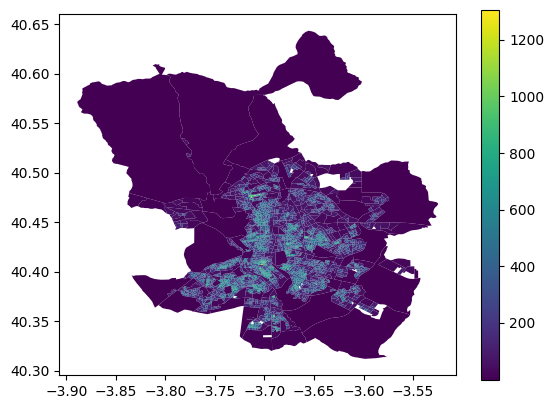

In [27]:
gg.plot('density', cmap='viridis', legend=True)

In [15]:
gg.total_population.isna().sum()

2442

In [9]:
import duckdb
import pandas as pd
import geopandas as gpd
from rampa.config import config

db_connection = duckdb.connect(config.paths['pois_db'])

df = db_connection.execute(
        f"""
        SELECT *
        FROM fact_demographics_age_groups fd
        JOIN dim_geography dg
        ON fd.census_section_id = dg.census_section_id
        """
    ).fetchdf()

df.drop('geom', axis=1, inplace=True)

In [10]:
from rampa.analysis.tools import cumulative

In [3]:
dic = cumulative(df, 'total')

In [4]:
dic.keys()

dict_keys(['total'])

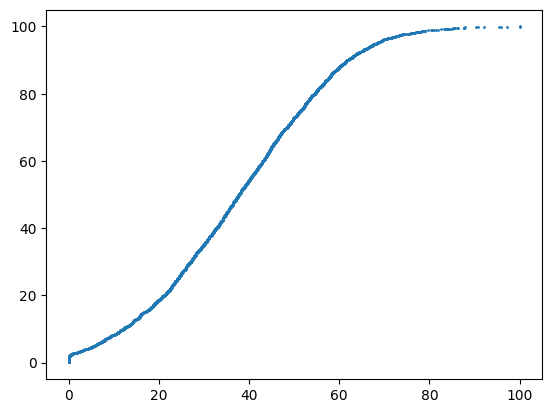

In [6]:
from matplotlib import pyplot as plt 
for key, item in dic.items():
    x = item[0]
    y = item[1]
    plt.scatter(x, y, label=key, s=1)

In [25]:
dd = df[df['gender']=='ALL']

In [26]:
dd.age_group.unique()

array(['00_04', '05_09', '10_14', '15_19', '20_24', '25_29', '30_34',
       '35_39', '40_44', '45_49', '50_54', '55_59', '60_64', '65_69',
       '70_74', '75_79', '80_84', '85_89', '90_94', '95_99', '100_más'],
      dtype=object)

In [27]:
dd = dd[dd['age_group'].isin(['65_69',
       '70_74', '75_79', '80_84', '85_89', '90_94', '95_99', '100_más'])]

In [28]:
sec = gpd.read_file(config.paths['data_dir']+'/seccion.geojson')
sec = sec.rename(columns={
        'COD_SECCIO': 'census_section_id'
    })
dd = dd.groupby('census_section_id').agg(
        {
            'population_count': 'sum',
            'district_id': 'first',
            'district_name': 'first',
            'neighborhood_id': 'first',
            'neighborhood_name': 'first',
        }
    )
dd.reset_index(inplace=True)
merged = sec.merge(dd, on='census_section_id', how='left')
# Drop rows with missing values in 'population_count' or 'ratio'
data = merged.dropna(subset=['population_count', 'ratio'])

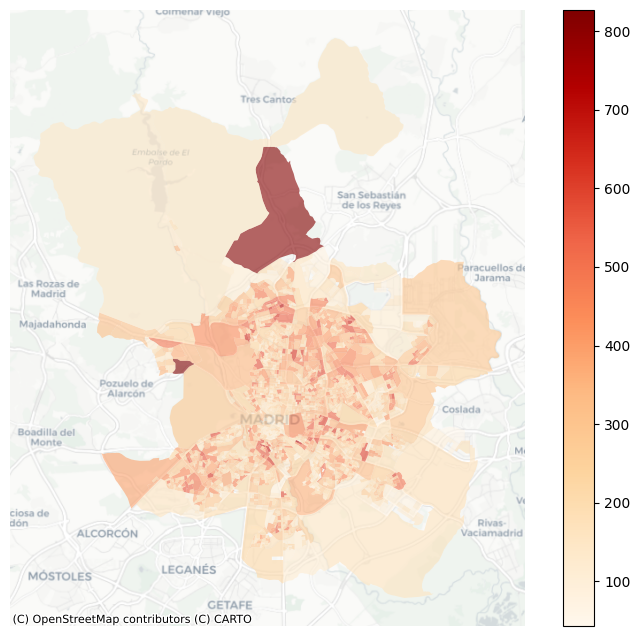

In [47]:
import contextily as ctx
ax = data.plot(column='population_count', cmap='OrRd', legend=True, figsize=(10,8), alpha = 0.6)
ax.set_axis_off()
ctx.add_basemap(ax, crs=data.crs.to_string(), source=ctx.providers.CartoDB.Positron)

In [32]:
data.population_count.sum()

690229.0

array([[<Axes: title={'center': 'population_count'}>]], dtype=object)

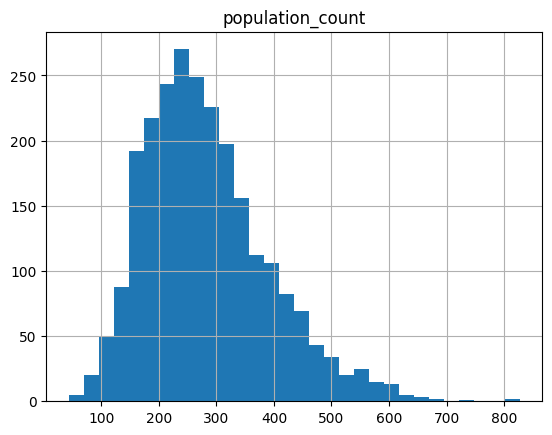

In [43]:
data.hist(column='population_count', bins=30)